In [1]:
import pandas as pd
import numpy as np
data1=pd.read_csv('red_line.csv')
data2=pd.read_csv('blue_line.csv')
data1.head()

,x,y
0,-5.0,37.500
1,-4.9,36.015
2,-4.8,34.560
3,-4.7,33.135
4,-4.6,31.740


In [2]:
X1=data1.loc[:,'x']
y1=data1.loc[:,'y']
X2=data2.loc[:,'x']
y2=data2.loc[:,'y']

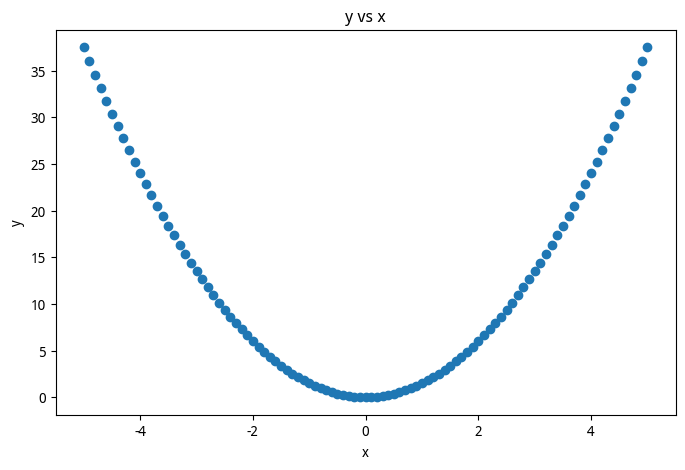

In [3]:
%matplotlib inline
from matplotlib import pyplot as plt
fig1=plt.figure(figsize=(8,5))
plt.scatter(X1,y1)
plt.title('y vs x')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [4]:
X1=np.array(X1).reshape(-1,1)
print(X1.shape)

(101, 1)


In [5]:
from keras.models import Sequential
from keras.layers import Dense,Input

model1=Sequential()
model1.add(Input(shape=(1,)))
model1.add(Dense(units=50,activation='relu'))
model1.add(Dense(units=50,activation='relu'))
model1.add(Dense(units=1,activation='linear'))
model1.compile(optimizer='adam',loss='mean_squared_error')
model1.summary()

2025-11-05 18:22:44.103089: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-05 18:22:44.103135: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-05 18:22:44.104484: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 50)                100       
                                                                 
 dense_1 (Dense)             (None, 50)                2550      
                                                                 
 dense_2 (Dense)             (None, 1)                 51        
                                                                 
Total params: 2701 (10.55 KB)
Trainable params: 2701 (10.55 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [6]:
model1.fit(X1,y1,epochs=100)

Epoch 1/100


I0000 00:00:1762338166.947835    6611 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4/4 [==============================] - -8s 5ms/step - loss: 287.0002
Epoch 2/100
4/4 [==============================] - 0s 4ms/step - loss: 277.6598
Epoch 3/100
4/4 [==============================] - 0s 3ms/step - loss: 269.2309
Epoch 4/100
4/4 [==============================] - 0s 5ms/step - loss: 260.3946
Epoch 5/100
4/4 [==============================] - 0s 6ms/step - loss: 252.2036
Epoch 6/100
4/4 [==============================] - 0s 4ms/step - loss: 244.0974
Epoch 7/100
4/4 [==============================] - 0s 3ms/step - loss: 235.7245
Epoch 8/100
4/4 [==============================] - 0s 3ms/step - loss: 227.3650
Epoch 9/100
4/4 [==============================] - 0s 3ms/step - loss: 219.1120
Epoch 10/100
4/4 [==============================] - 0s 3ms/step - loss: 210.2711
Epoch 11/100
4/4 [==============================] - 0s 3ms/step - loss: 201.8686
Epoch 12/100
4/4 [==============================] - 0s 3ms/step - loss: 192.9590
Epoch 13/100
4/4 [==============================

In [7]:
y1_predict=model1.predict(X1)

4/4 [==============================] - 0s 2ms/step


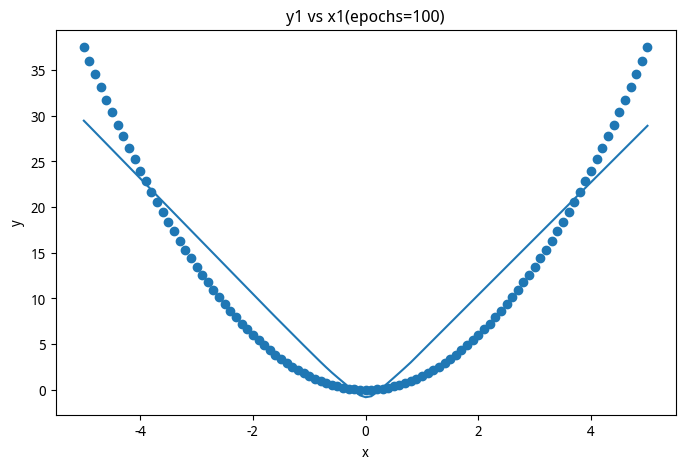

In [8]:
fig2=plt.figure(figsize=(8,5))
plt.scatter(X1,y1)
plt.plot(X1,y1_predict)
plt.title('y1 vs x1(epochs=100)')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [9]:
model1.fit(X1,y1,epochs=500)

Epoch 1/500
4/4 [==============================] - 0s 3ms/step - loss: 12.8127
Epoch 2/500
4/4 [==============================] - 0s 3ms/step - loss: 12.6178
Epoch 3/500
4/4 [==============================] - 0s 3ms/step - loss: 12.4489
Epoch 4/500
4/4 [==============================] - 0s 3ms/step - loss: 12.2996
Epoch 5/500
4/4 [==============================] - 0s 3ms/step - loss: 12.1076
Epoch 6/500
4/4 [==============================] - 0s 2ms/step - loss: 11.9518
Epoch 7/500
4/4 [==============================] - 0s 3ms/step - loss: 11.8097
Epoch 8/500
4/4 [==============================] - 0s 2ms/step - loss: 11.6513
Epoch 9/500
4/4 [==============================] - 0s 3ms/step - loss: 11.4880
Epoch 10/500
4/4 [==============================] - 0s 3ms/step - loss: 11.3139
Epoch 11/500
4/4 [==============================] - 0s 2ms/step - loss: 11.1392
Epoch 12/500
4/4 [==============================] - 0s 3ms/step - loss: 10.9977
Epoch 13/500
4/4 [==============================]

4/4 [==============================] - 0s 1ms/step


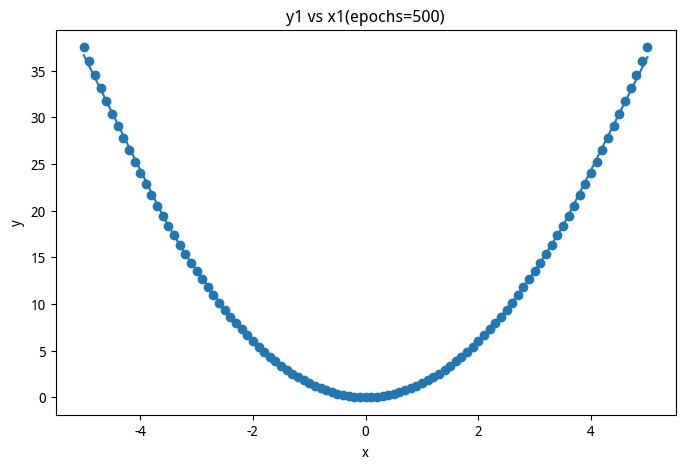

In [10]:
y1_predict=model1.predict(X1)
fig3=plt.figure(figsize=(8,5))
plt.scatter(X1,y1)
plt.plot(X1,y1_predict)
plt.title('y1 vs x1(epochs=500)')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [11]:
import joblib
joblib.dump(model1,'model1.m')

['model1.m']

In [12]:
model2=joblib.load('model1.m')
X2=np.array(X2).reshape(-1,1)
print(X2.shape)

(101, 1)


In [13]:
y2_predict=model2.predict(X2)
print(y2_predict.shape)

4/4 [==============================] - 0s 2ms/step
(101, 1)


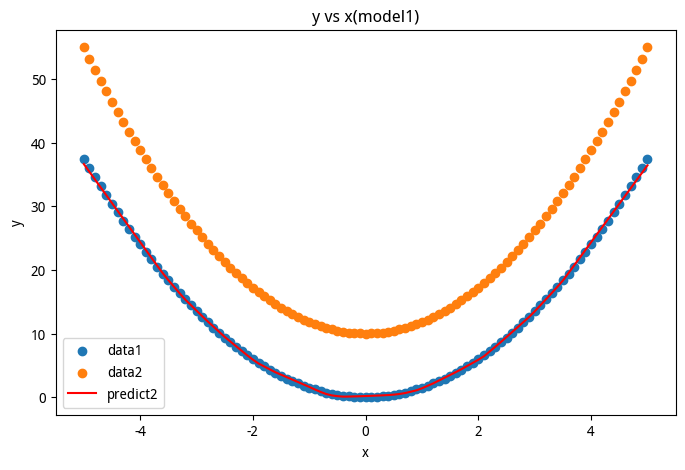

In [14]:
fig4=plt.figure(figsize=(8,5))
plt.scatter(X1,y1,label='data1')
plt.scatter(X2,y2,label='data2')
plt.plot(X2,y2_predict,'r',label='predict2')
plt.title('y vs x(model1)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [15]:
model2.fit(X2,y2,epochs=50)

Epoch 1/50
4/4 [==============================] - 0s 5ms/step - loss: 143.8885
Epoch 2/50
4/4 [==============================] - 0s 5ms/step - loss: 63.9770
Epoch 3/50
4/4 [==============================] - 0s 5ms/step - loss: 21.2754
Epoch 4/50
4/4 [==============================] - 0s 5ms/step - loss: 26.0784
Epoch 5/50
4/4 [==============================] - 0s 5ms/step - loss: 30.4504
Epoch 6/50
4/4 [==============================] - 0s 5ms/step - loss: 17.8084
Epoch 7/50
4/4 [==============================] - 0s 5ms/step - loss: 9.6810
Epoch 8/50
4/4 [==============================] - 0s 4ms/step - loss: 10.1953
Epoch 9/50
4/4 [==============================] - 0s 4ms/step - loss: 10.4459
Epoch 10/50
4/4 [==============================] - 0s 4ms/step - loss: 8.6841
Epoch 11/50
4/4 [==============================] - 0s 4ms/step - loss: 6.4712
Epoch 12/50
4/4 [==============================] - 0s 6ms/step - loss: 5.7265
Epoch 13/50
4/4 [==============================] - 0s 4ms/step -

4/4 [==============================] - 0s 2ms/step


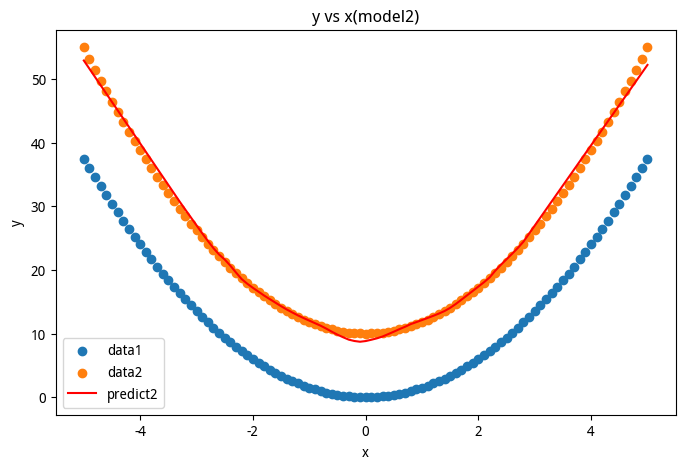

In [16]:
y2_predict=model2.predict(X2)
fig5=plt.figure(figsize=(8,5))
plt.scatter(X1,y1,label='data1')
plt.scatter(X2,y2,label='data2')
plt.plot(X2,y2_predict,'r',label='predict2')
plt.title('y vs x(model2)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()